In [1]:
import sys
sys.path.append("..")

import numpy as np
from numpy.linalg import norm
from scipy.linalg import expm, block_diag

import matplotlib.pyplot as plt
from lunanav.constants import GM_MOON, R_MOON
from lunanav.sim.simulator import SimParams, SimResults, run_sim, RigidBody, calc_measurements, SensorNoises
from lunanav.sim.sensors import get_los_vectors, alt_from_los
from lunanav.plotting import debug_3d, plot_state_vector, plot_control_effort
from lunanav.visualization import visualize_trajectory
from lunanav.sim.quaternion import angle_axis_to_q, mul, quat_apply, unit, unitize_state
from lunanav.estimation.ekf import EkfParams, ekf_predict, ekf_update
import jax
import jax.numpy as jnp

# Sim!

In [2]:
lander = RigidBody(
    mass_kg = 100,
    I = np.eye(3)
)

dt = .1
t0 = 0
t_max = 40
nsteps = int(t_max//dt)

state0 = np.array([
    0,0, R_MOON + 3, 
    0 ,0, 0,
    1,0,0,0, 
    0,0,0])


In [3]:
def control_fn(t, state):
    """Outputs inputs in body frame"""
    del state
    force_N = np.zeros(3)
    torque_Nm = np.zeros(3)

    # ----- Thrust -----
    if t < 5:
        force_N += [0,0,6e2/2]

    elif t < 25:
        force_N += [0,0,8e2/2]

    elif t < 80:
        force_N += [0,0,30e2/2]

    # ----- Torque -----

    if t < 6:
        torque_Nm += [0.007, 0, 0]
    elif t < 18:
        torque_Nm += [-0.005, 0, 0]
    elif t < 36:
        torque_Nm += [0.003, 0, 0]
    elif t < 54:
        torque_Nm += [-0.003, 0, 0]

    return force_N, torque_Nm


## Simulate

In [4]:
sim = SimParams(state0, lander, dt, nsteps)
results = run_sim(state0, nsteps, dt, control_fn, sim)
n = results.nsteps

In [5]:
moon_offset =  np.tile([0,0,R_MOON,0,0,0,0,0,0,0,0,0,0], (n, 1))

other_vecs = {
    "names": ["LOS1", "LOS2", "LOS3", "LOS4"],
    "vecs": get_los_vectors(),
    "colors": ['green', 'green', 'green', 'green'],
    "scale": 1e3
}


In [6]:
if 1:
    other_vecs = {
        "names": ["LOS1", "LOS2", "LOS3", "LOS4"],
        "vecs": get_los_vectors(),
        "colors": ['green', 'green', 'green', 'green'],
        "scale": 1e5
    }
    fig = visualize_trajectory(results.states - moon_offset, results.t, dt, title="Lunar Descent Trajectory with LOS Vectors", show_lander=False, other_vecs=other_vecs)
    fig.show()

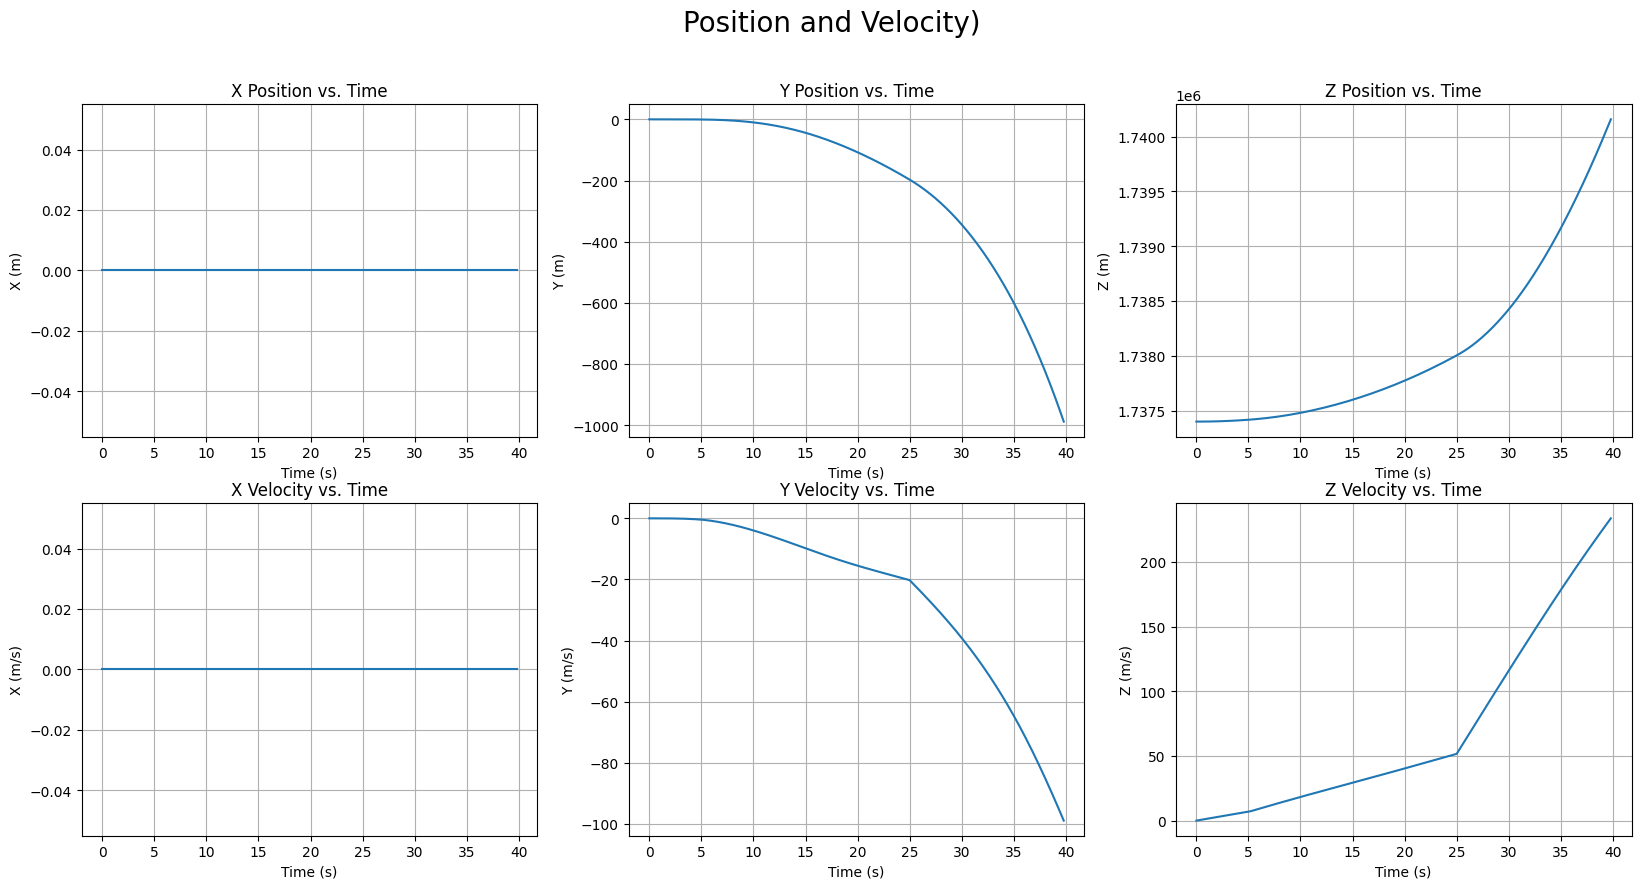

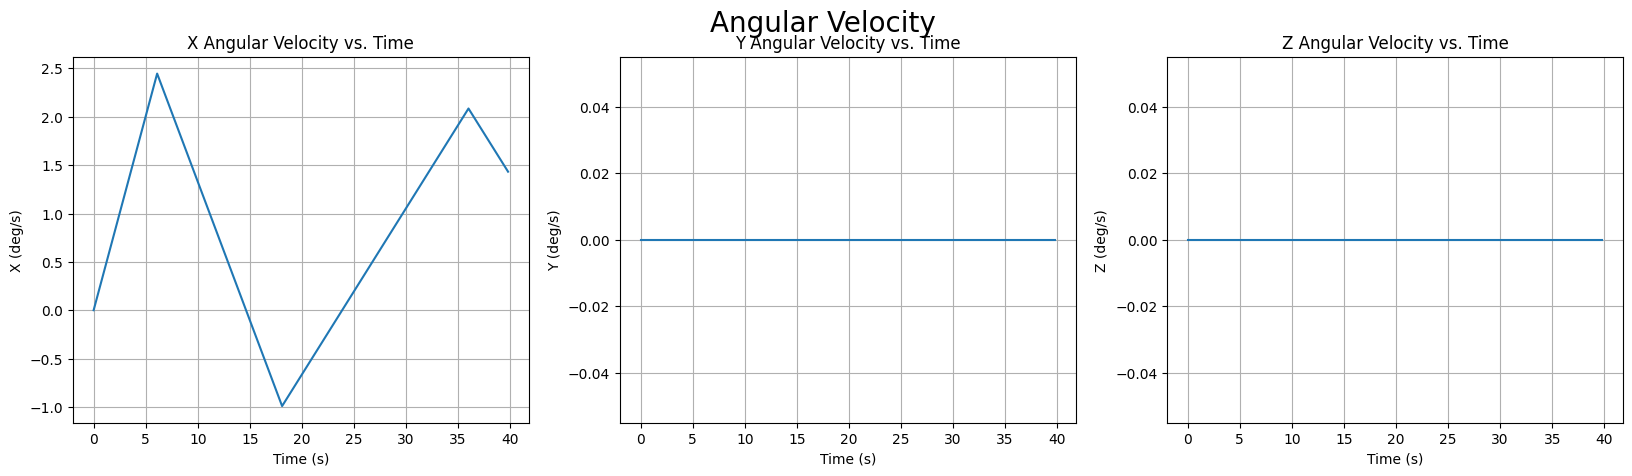

In [7]:
plot_state_vector(results.t, results.states[:,0:3], results.states[:,3:6], results.states[:,10:13])

## Meas

In [8]:
# Calculate line-of-sight measurements
# Make sensor noise
R_accel = np.eye(3)*0.1  # m/s^2
R_gyro = np.eye(3)*0.0001  # rad/s^2
R_los = np.eye(4)*10  # m

truth_meas = calc_measurements(results, lander.mass_kg)
noise_meas = calc_measurements(results, lander.mass_kg, SensorNoises(R_accel, R_gyro, R_los))

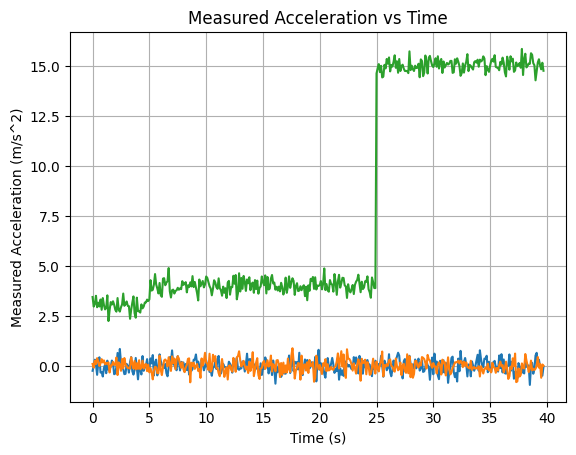

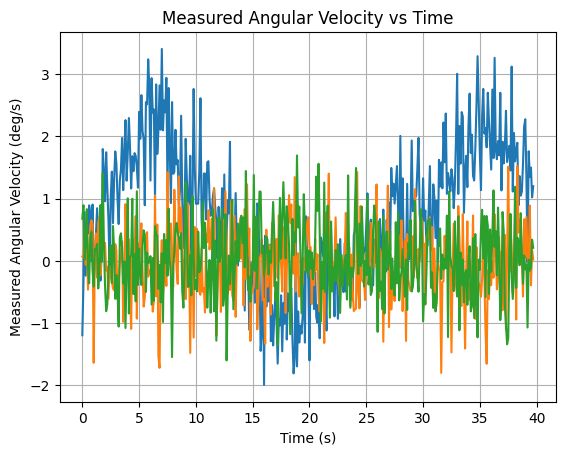

In [9]:
from lunanav.constants import RAD_TO_DEG

plt.plot(results.t[:-1], noise_meas.accel[:-1])
plt.xlabel("Time (s)")
plt.ylabel("Measured Acceleration (m/s^2)")
plt.title("Measured Acceleration vs Time")
plt.grid()
plt.show()

plt.plot(results.t[:-1], noise_meas.gyro[:-1] * RAD_TO_DEG)
plt.xlabel("Time (s)")
plt.ylabel("Measured Angular Velocity (deg/s)")
plt.title("Measured Angular Velocity vs Time")
plt.grid()
plt.show()

### EKF

In [10]:

def ekf_meas(state):
    """Measurement function for EKF"""
    meas_arr = alt_from_los(state)
    return meas_arr

# Compute the Jacobian
ekf_meas_jacobian = jax.jacfwd(ekf_meas)

state_example = results.states[30]

# Print the measurement output
print("Measurement Output:", ekf_meas(state_example))

# Print the Jacobian
print(ekf_meas_jacobian(state_example).shape)

Measurement Output: [-13.024438 -13.024438 -12.45669  -12.45669 ]
(4, 13)


In [11]:
def Qd_from_accel_white(dt, sigma_a):

    # 2x2 covariance for (pos, vel) driven by white accel noise in ONE axis
    Q1 = np.array([
        [dt**3/3, dt**2/2],
        [dt**2/2, dt     ]
    ]) * (sigma_a**2)

    # Build block-diagonal structure for x, y, z axes.
    # At this point the order is [x, xd, y, yd, z, zd]
    Q_block = block_diag(Q1, Q1, Q1)

    # Reorder rows/cols to match OUR state order: [x, y, z, xd, yd, zd]
    # This permutation swaps (pos, vel) pairs into the correct structure.
    perm = np.array([0, 2, 4,   1, 3, 5])
    Q6 = Q_block[np.ix_(perm, perm)]

    return Q6

In [12]:

# Q6 = Qd_from_accel_white(dt, sigma_a)
# Q = np.zeros((13,13))
# Q[0:6, 0:6] = Q6
# Q[6:10, 6:10] = np.eye(4) * 1e-6 # small process noise on quaternion to prevent filter divergence
# Q[10:13, 10:13] = np.eye(3) * 1e-6 # small process noise on angular velocity

Q = np.eye(13) * 1e-6 # for testing, use small process noise to see if EKF can track without it

# sigma_w = 0.01  # rad/s^2
# R = np.zeros((6,6))
# R[0:3,0:3] = np.eye(3) * (sigma_a**2)
# R[3:6,3:6] = np.eye(3) * (sigma_w**2)

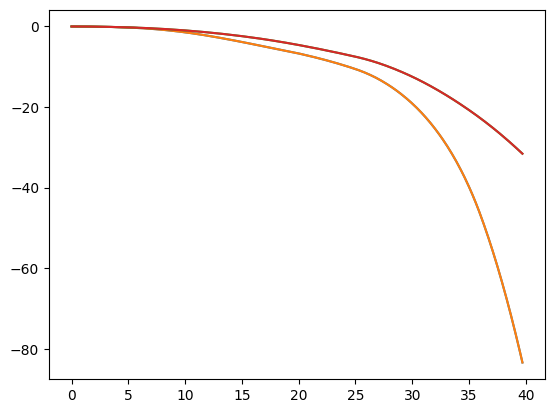

In [13]:
# plt.plot(truth_meas.gyro)
plt.plot(results.t[:-1], truth_meas.laser_alt[:-1] / lander.mass_kg)

In [14]:
mu_arr = np.zeros((n, 13))
Sigma_arr = np.zeros((n, 13, 13))

mu_arr[0] = state0
Sigma_arr[0] = np.eye(13) * 1e-3

n_new = n

for i in range(n_new-1):
    # force, torque = control_fn(results.t[i], results.states[i])
    mu_pred, Sigma_pred = ekf_predict(mu_arr[i], Sigma_arr[i], truth_meas.accel[i], truth_meas.gyro[i], Q, sim)
    mu_pred = unitize_state(mu_pred)

    # if results.t[i] < 30:
    mu_pred, Sigma_pred = ekf_update(mu_pred, Sigma_pred, truth_meas.laser_alt[i], ekf_meas_jacobian(mu_pred), ekf_meas(mu_pred),R_los)

    mu_pred = unitize_state(mu_pred)

    mu_arr[i+1] = mu_pred
    Sigma_arr[i+1] = Sigma_pred

    # mu_arr[i+1] = mu_update
    # Sigma_arr[i+1] = Sigma_update

    t = results.t[i+1]
    x_est = mu_pred
    truth = results.states[i+1]
    a_meas = truth_meas.accel[i]
    w_meas = truth_meas.gyro[i]
    P = Sigma_pred
    
    # In your EKF loop:
    # print(f"t={t:6.2f}: "
    #     f"||q||={np.linalg.norm(x_est[6:10]):.8f} "
    #     f"q_err={np.linalg.norm(truth[6:10] - x_est[6:10]):.6f} "
    #     f"v_err={np.linalg.norm(truth[3:6] - x_est[3:6]):.4f} "
    #     f"p_err={np.linalg.norm(truth[0:3] - x_est[0:3]):.4f} "
    #     f"||P_qq||={np.linalg.norm(P[6:10, 6:10]):.2e} "
    #     f"||a_meas||={np.linalg.norm(a_meas):.4f} "
    #     f"||w_meas||={np.linalg.norm(w_meas):.6f}")
    # z = results.states[i+1][0:6]  # True next state (pos and vel)
    # H = np.hstack([np.eye(6), np.zeros((6,4))])  # Measurement matrix to extract pos and vel
    # mu0, Sigma0 = ekf_update(mu_pred, Sigma_pred, z, H, R)

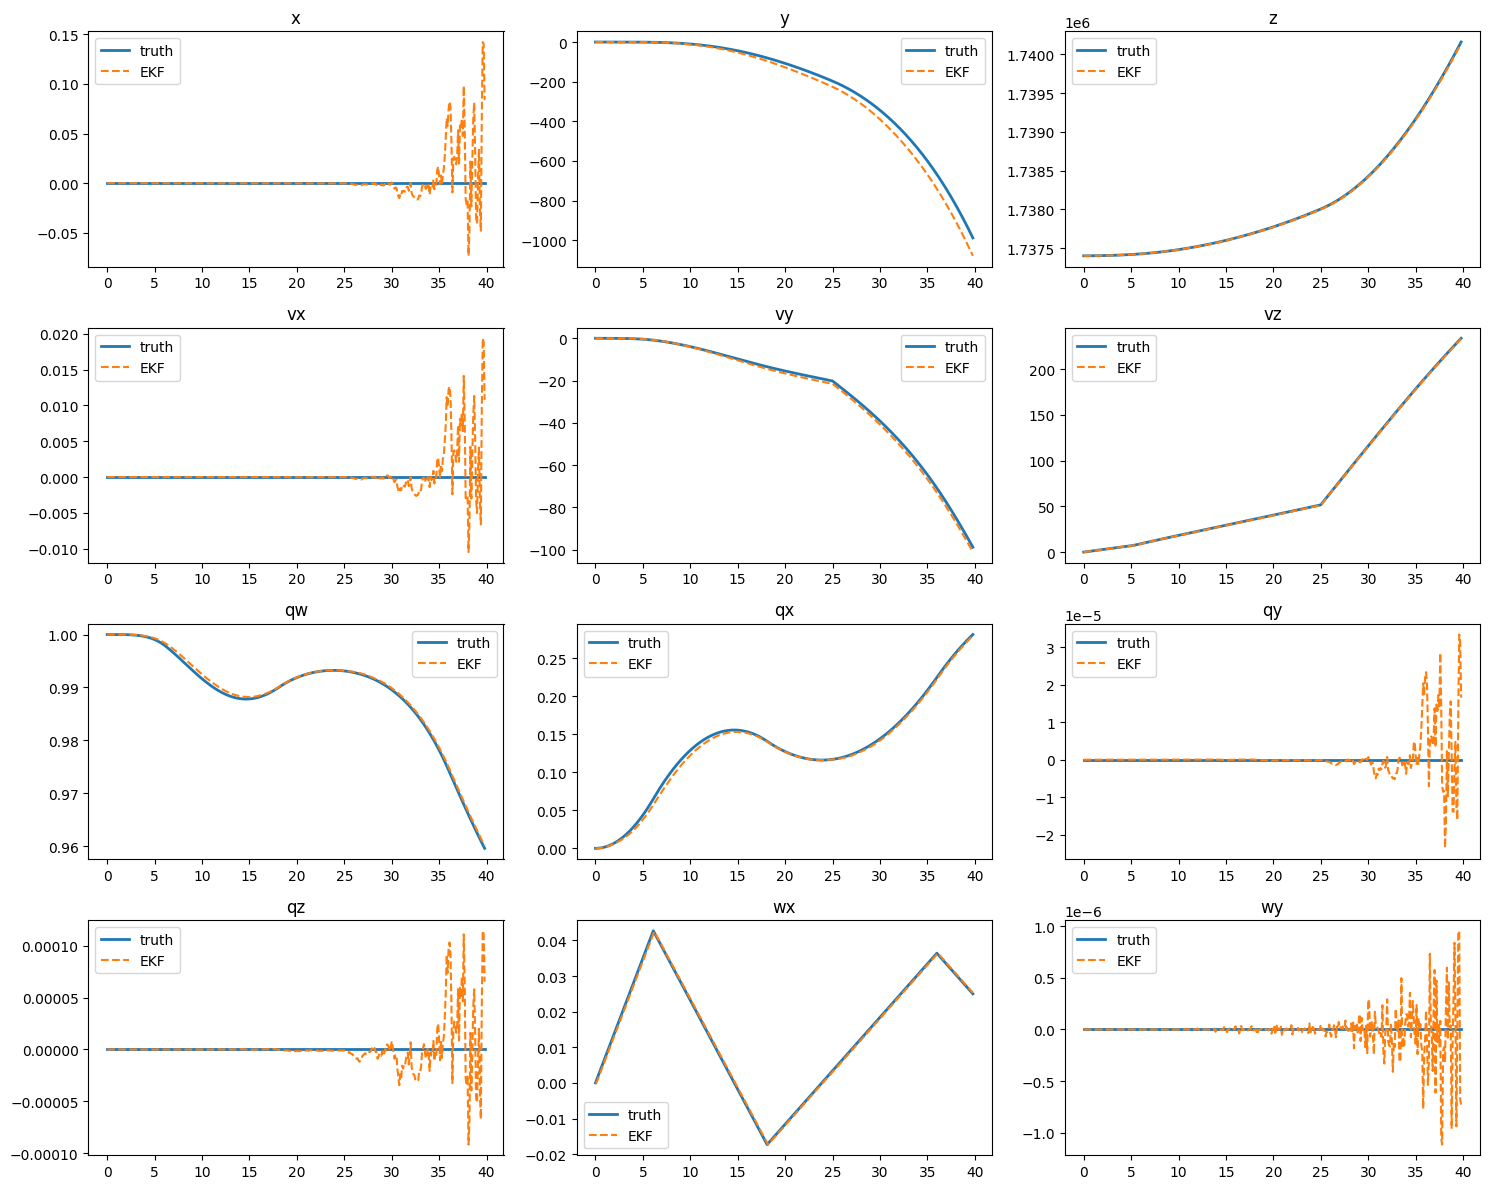

In [15]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
labels = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'qw', 'qx', 'qy', 'qz', 'wx', 'wy']
for i, ax in enumerate(axes.flatten()):
    ax.plot(results.t, results.states[:, i], label='truth', linewidth=2)
    ax.plot(results.t, mu_arr[:, i], label='EKF', linestyle='--')
    # ax.fill_between(results.t, est[:, i] - 3*np.sqrt(P[:, i, i]),z
    ax.set_title(labels[i])
    ax.legend()
plt.tight_layout()
plt.show()

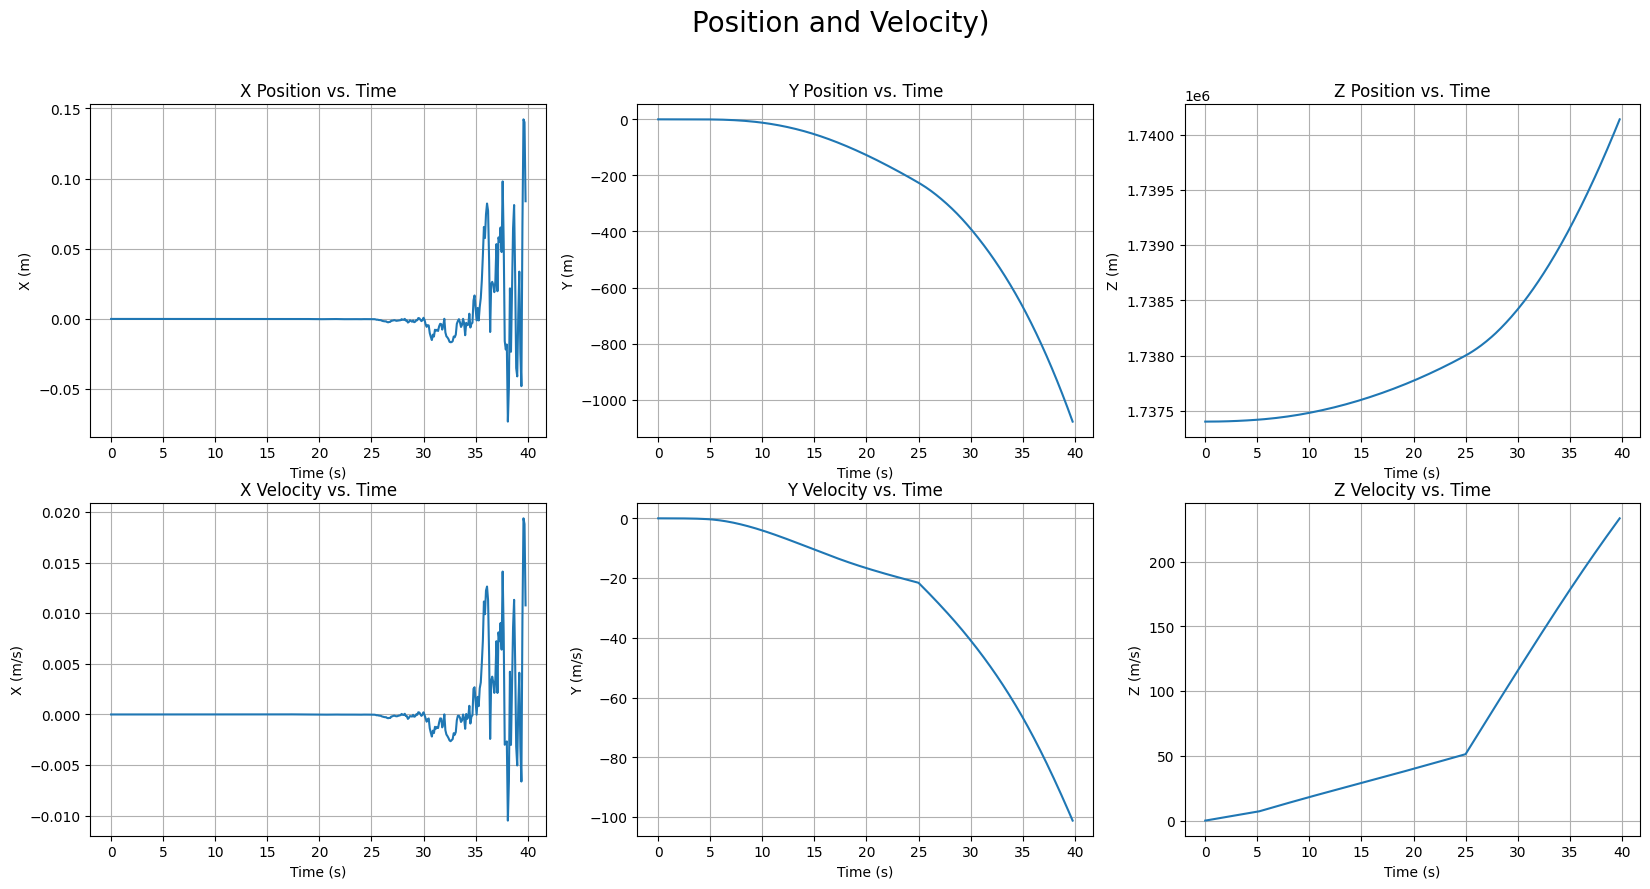

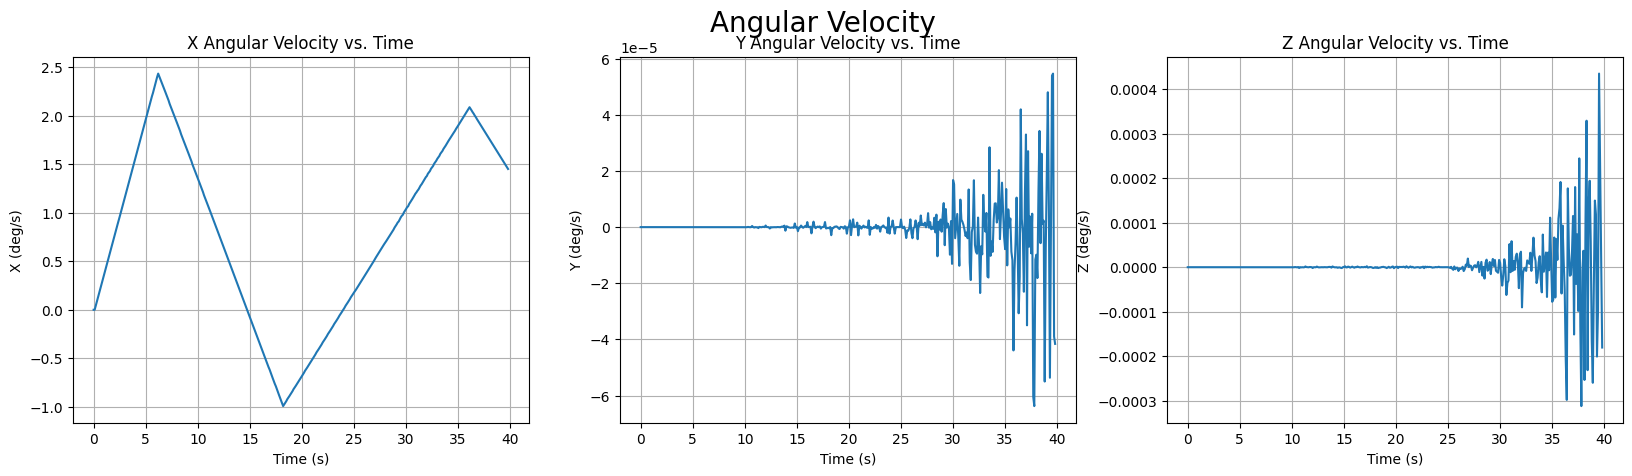

In [16]:
plot_state_vector(results.t, mu_arr[:,0:3], mu_arr[:,3:6], mu_arr[:,10:13])

In [17]:
visualize_trajectory(mu_arr - moon_offset, results.t, dt, title="EKF Estimated Trajectory with LOS Vectors", show_lander=False).show()

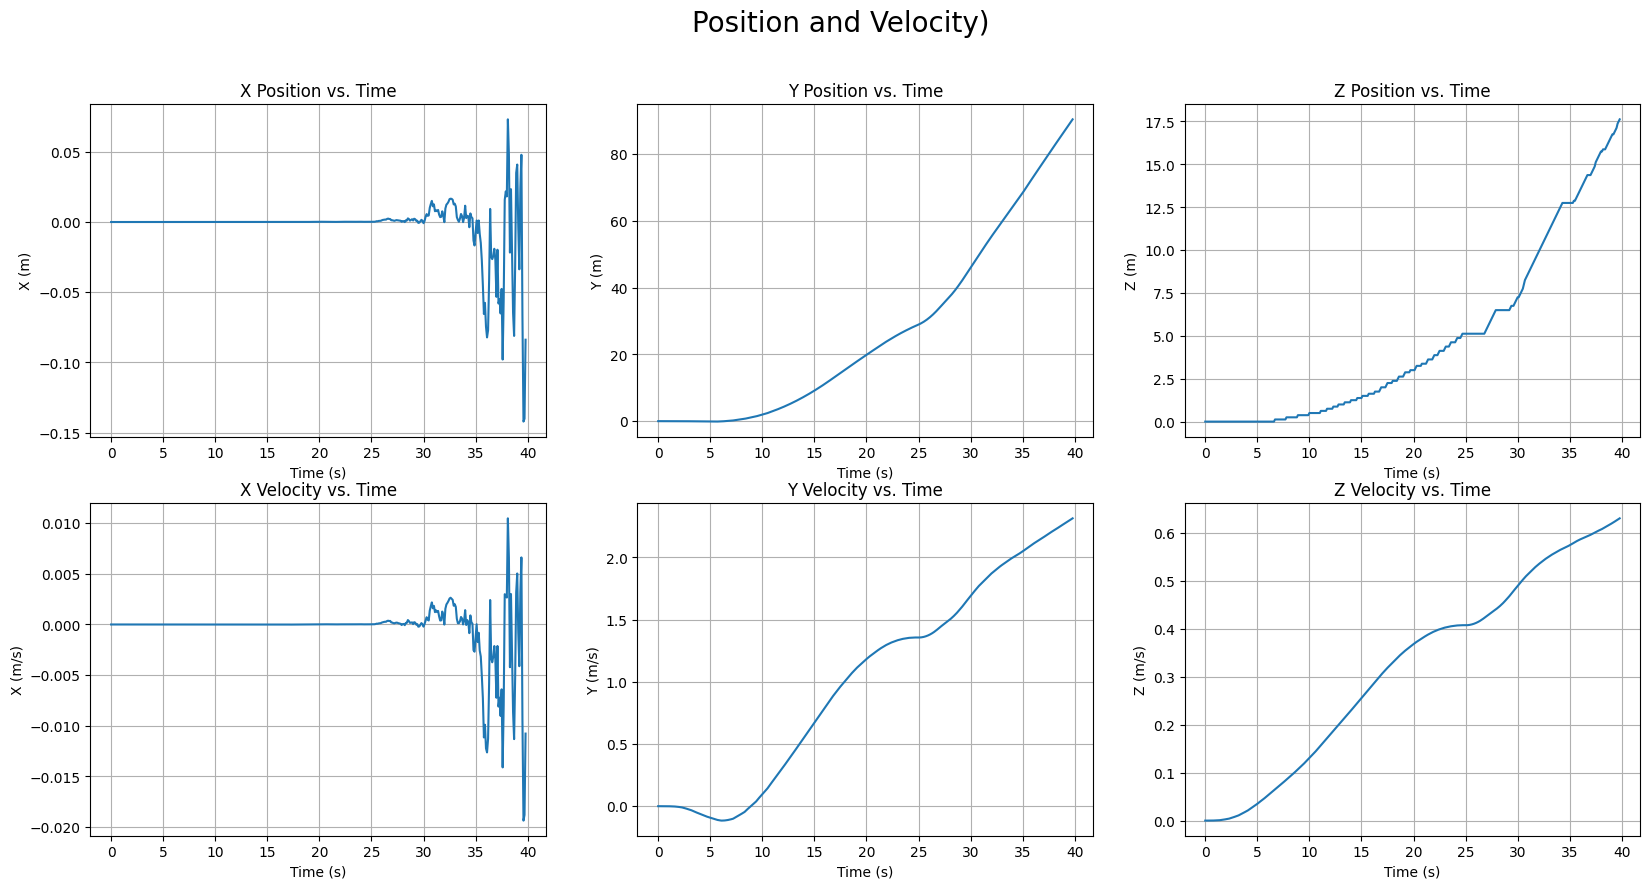

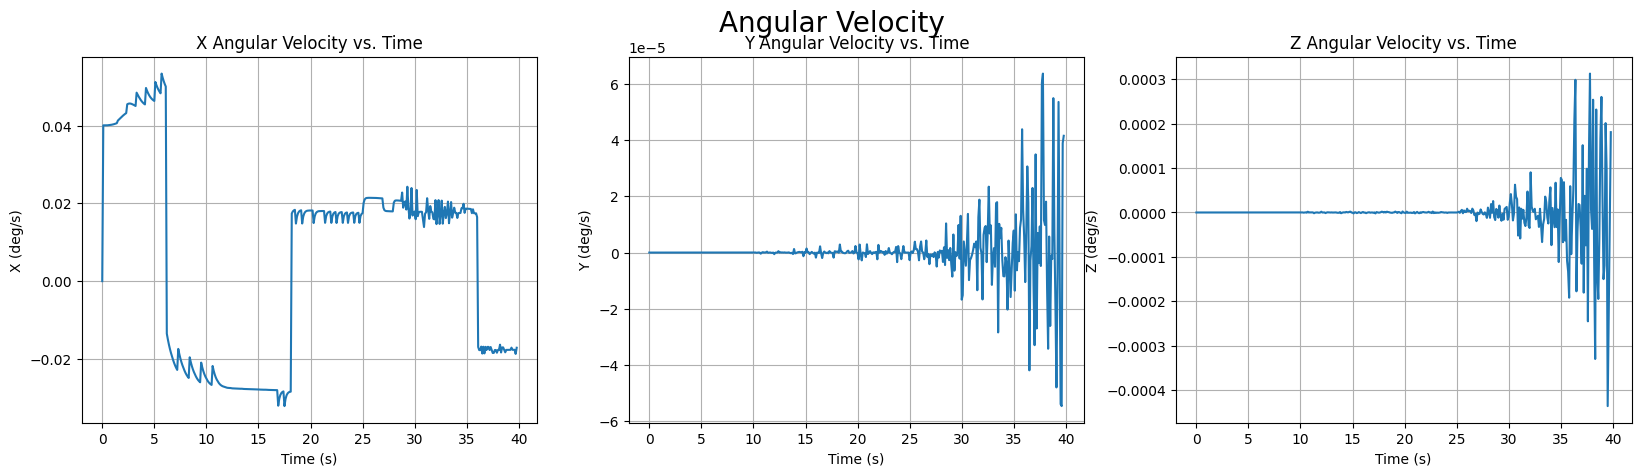

In [18]:
plot_state_vector(results.t, results.states[:,0:3] - mu_arr[:,0:3], results.states[:,3:6] - mu_arr[:,3:6], results.states[:,10:13] - mu_arr[:,10:13])

In [19]:
# mu_arr[:,2] - results.states[:,2]
# print(mu_arr[0,2].dtype)
# print(results.states[0,2].dtype)
# print(P.dtype)

state = mu_arr[22,:]
x_est = results.states[22,:]

print("Measured alts:", alt_from_los(state))
print("Expected alts:", alt_from_los(x_est))

Measured alts: [-8.755501 -8.755501 -8.572483 -8.572483]
Expected alts: [-8.768342 -8.768342 -8.560747 -8.560747]


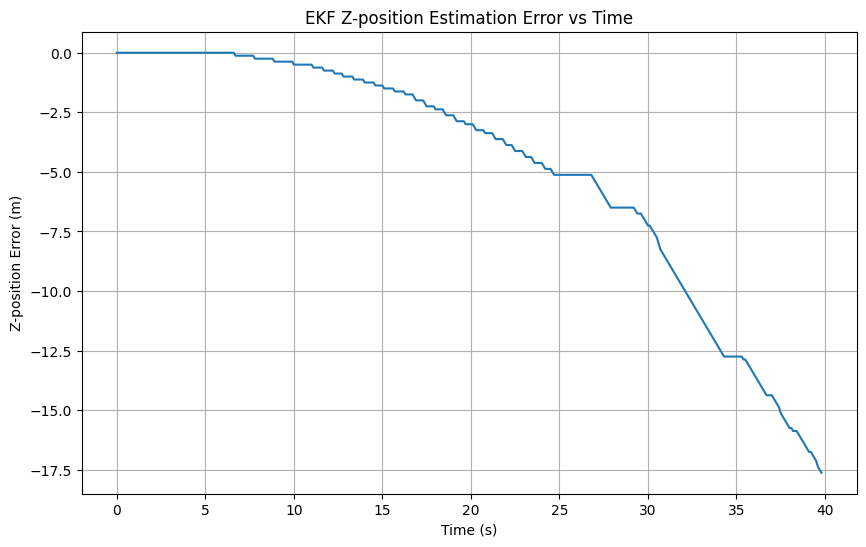

In [20]:
plt.figure(figsize=(10,6))
plt.plot(results.t, mu_arr[:,2] - results.states[:,2])
plt.xlabel("Time (s)")
plt.ylabel("Z-position Error (m)")
plt.title("EKF Z-position Estimation Error vs Time")
plt.grid()
# plt.legend()
plt.show()